In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import random

import pickle as pkl
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainwidemap import bwm_query, bwm_units, load_good_units, load_trials_and_mask
from tqdm import tqdm
from one.api import ONE
from brainbox.singlecell import bin_spikes2D
from iblatlas.regions import BrainRegions
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
from ibl_info.utils import check_config

In [4]:
config = check_config()
MY_REGIONS = config["stim_prior_regions"]
MIN_NEURONS = config["min_units"]
BIN_SIZE = 0.0125
STRIDE = 0.002
USE_SLIDING_WINDOW = True

EPOCHS = {
    "Quiescent": {"align": "stimOn_times", "window": (0.6, 0.0)},
    "Stimulus": {"align": "stimOn_times", "window": (0.0, 0.15)},
    "Choice": {"align": "firstMovement_times", "window": (0.15, 0.0)},
}

In [6]:
with open("../data/generated/manifold/bwm_accumulated_data_correct_incorrect.pkl", "rb") as f:
    dx = pkl.load(f)

In [14]:
pop_matrix = np.vstack(dx["ACAd"]["Choice"])

In [ ]:
pop_matrix.shape # huge pseudo session

(351, 120)

In [16]:
n_bins = int(pop_matrix.shape[1] / 8)

In [18]:
reshaped = np.transpose(pop_matrix.reshape(pop_matrix.shape[0], 8, n_bins), (1, 2, 0))

In [30]:
from ibl_info.rsa_regression import ideal_rsa_matrices
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import pdist, squareform
from scipy.stats import zscore

In [39]:
accumulated_data = dx
results = {}
normalization = False
model_vectors, model_names = ideal_rsa_matrices()

In [28]:
X = np.column_stack([model_vectors[name] for name in model_names])

In [ ]:
for region in accumulated_data.keys():
    results[region] = {}
    epochs = ["Quiescent", "Stimulus", "Choice"]
    
    for epoch in epochs:
        session_matrices = accumulated_data[region][epoch]
        if not session_matrices:
            continue

        pop_matrix = np.vstack(session_matrices)

        if normalization:
            pop_matrix = zscore(pop_matrix, axis=1)
            pop_norm = np.nan_to_num(pop_norm)

        n_bins = int(pop_matrix.shape[1] / 8)
        reshaped = np.transpose(pop_matrix.reshape(pop_matrix.shape[0], 8, n_bins), (1, 2, 0))
        betas_over_time = np.zeros((n_bins, len(model_names)))

        reg = LinearRegression(fit_intercept=True)

        for t in range(n_bins):
            trajectories = reshaped[:, t, :]

            y = pdist(trajectories, "euclidean")

            reg.fit(X, y)
            betas_over_time[t, :] = reg.coef_

        results[region][epoch] = betas_over_time

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


def plot_full_fingerprint(results, model_names):
    """
    Plots the average beta weight for EVERY model in EVERY epoch.
    Generates a faceted bar chart: Columns = Epochs, Hue = RSA Model.
    """
    summary_data = []

    # Define the order for plotting
    epochs_ordered = ["Quiescent", "Stimulus", "Choice"]

    # 1. Aggregate Data
    for region, epochs_data in results.items():
        for epoch in epochs_ordered:
            if epoch not in epochs_data:
                continue

            # Get the matrix of betas: (Time_Bins, 4_Models)
            betas = epochs_data[epoch]

            # Calculate the mean for each model across the entire epoch
            for k, model_name in enumerate(model_names):
                mean_beta = np.mean(betas[:, k])

                summary_data.append(
                    {"Region": region, "Epoch": epoch, "Model": model_name, "Beta": mean_beta}
                )

    if not summary_data:
        print("No data found to plot.")
        return

    df = pd.DataFrame(summary_data)

    # 2. Plotting (Faceted by Epoch)
    # We use catplot to create a grid: 1 Row, 3 Columns (Quiescent, Stimulus, Choice)
    g = sns.catplot(
        data=df,
        kind="bar",
        x="Region",
        y="Beta",
        hue="Model",
        col="Epoch",
        col_order=epochs_ordered,
        palette="viridis",
        height=5,
        aspect=1.2,
        edgecolor="black",  # Adds border to bars for clarity
        linewidth=1,
    )

    # 3. Aesthetics
    g.set_axis_labels("Region", "Average Regression Weight (Beta)")
    g.set_titles("{col_name} Period")

    # Add a zero line to each subplot
    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1, linestyle="--")
        # Rotate x-labels if you have many regions
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

    return df  # Return the dataframe if you want to inspect the numbers


# --- Usage ---
# df_summary = plot_full_fingerprint(rsa_results, ["Choice", "Prior", "Outcome", "Stimulus"])

In [47]:
model_names = ["Choice", "Prior", "Outcome", "Stimulus"]

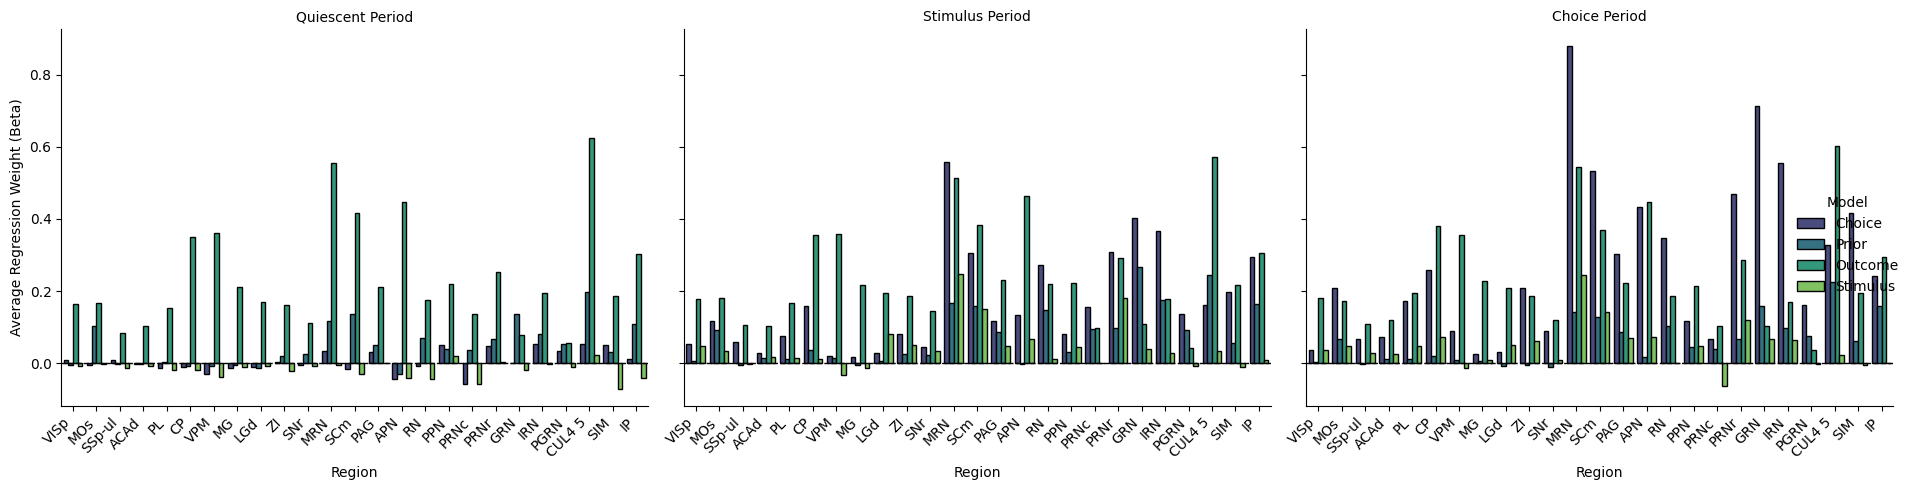

In [55]:
df = plot_full_fingerprint(results, model_names)

In [60]:
df.groupby(["Epoch", "Model"]).mean("Betas")

Beta
Epoch     Model             
Choice    Choice    0.272744
          Outcome   0.241064
          Prior     0.060764
          Stimulus  0.046527
Quiescent Choice    0.007268
          Outcome   0.235950
          Prior     0.048149
          Stimulus -0.016932
Stimulus  Choice    0.167111
          Outcome   0.241319
          Prior     0.080180
          Stimulus  0.043529

In [49]:
import matplotlib.pyplot as plt
import numpy as np


def plot_rsa_dynamics(results, model_names, bin_size=0.01):
    """
    Plots the time-course of RSA betas for each region.
    Assumes results structure: {region: {epoch: (n_bins, n_predictors)}}
    """
    # Define consistent colors for your 4 kernels
    colors = {
        "Choice": "#1f77b4",  # Blue
        "Prior": "#9467bd",  # Purple
        "Outcome": "#d62728",  # Red
        "Stimulus": "#2ca02c",  # Green
    }

    # Iterate over regions
    for region, epochs_data in results.items():
        if not epochs_data:
            continue

        # Create a figure with 3 subplots (one per epoch)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        fig.suptitle(f"{region} | Neural Information Dynamics", fontsize=16)

        epochs_ordered = ["Quiescent", "Stimulus", "Choice"]

        # Calculate global min/max for Y-axis scaling across all epochs
        all_vals = np.concatenate([v.flatten() for v in epochs_data.values()])
        y_max = np.percentile(all_vals, 99.5) * 1.1  # Robust max
        y_min = np.min(all_vals) * 1.1

        for i, epoch in enumerate(epochs_ordered):
            ax = axes[i]
            if epoch not in epochs_data:
                ax.axis("off")
                continue

            betas = epochs_data[epoch]
            n_bins = betas.shape[0]

            # Create time axis (seconds)
            # Adjust these start times based on your specific epoch definitions!
            if epoch == "Quiescent":
                t_start = -0.5
            elif epoch == "Stimulus":
                t_start = 0.0
            elif epoch == "Choice":
                t_start = -0.1  # Example: aligned to move

            t_axis = np.linspace(t_start, t_start + n_bins * bin_size, n_bins)

            # Plot each Kernel
            for k, name in enumerate(model_names):
                ax.plot(t_axis, betas[:, k], label=name, color=colors[name], lw=2.5)

            # Styling
            ax.set_title(epoch)
            ax.axhline(0, color="black", linestyle=":", alpha=0.5)  # Zero line
            ax.set_ylim(y_min, y_max)
            ax.grid(True, alpha=0.2)

            if i == 0:
                ax.set_ylabel("Kernel Strength (Beta)")
                ax.legend(loc="upper left", fontsize="small", frameon=False)
            if i == 1:
                ax.set_xlabel("Time (s)")

        plt.tight_layout()
        plt.show()

In [52]:
results["ACAd"]["Quiescent"].shape

(50, 4)